In [ ]:
import squidpy as sq
import numpy as np
from src import utils

c:\Users\laure\anaconda3\envs\new_spatial\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\laure\anaconda3\envs\new_spatial\Lib\site-packages\xarray_schema\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
adata = sq.datasets.merfish()

subsetting to single slide

In [4]:
adata = adata[adata.obs["batch"] == "0"]

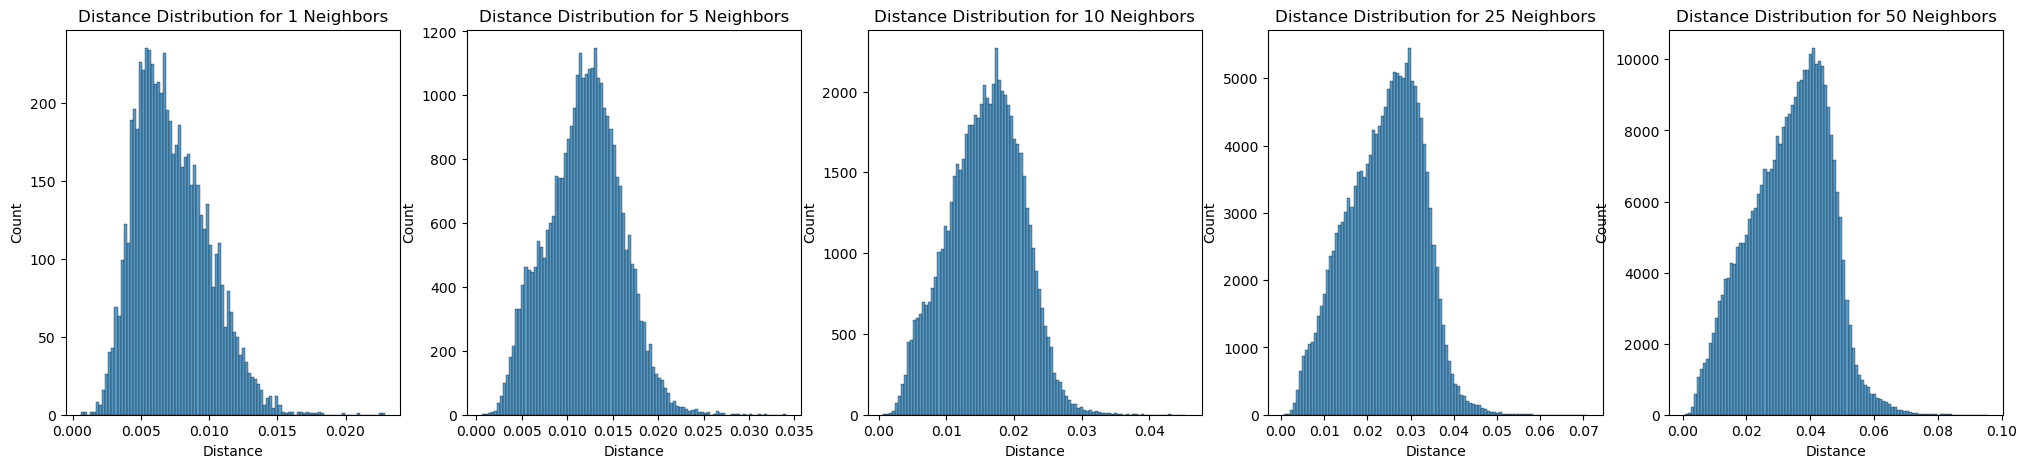

In [5]:
utils.plot_dist_histogram(adata, n_neighs_range=[1, 5, 10, 25, 50], bins=100)

- The more neighbors you allow i.e. the higher the distance from a cell -> the more cells will have the same distance
- smaller neighborhoods have much more variance in distances -> much more sensitive to distance cutoffs!

Now let's recreate the distance by neighbor plot which was used in the aKNNO paper to show where to apply thresholding:

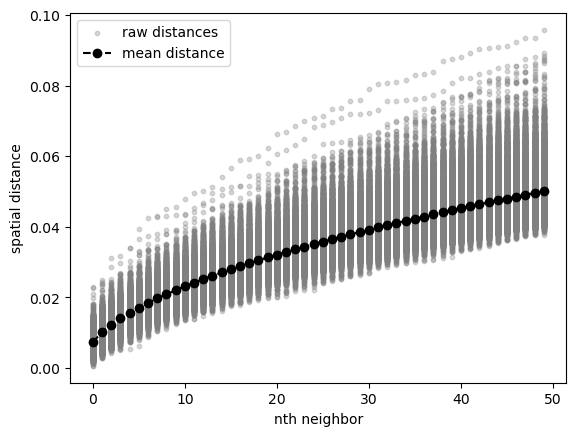

In [6]:
utils.plot_dist_by_neigh(adata, distances_key="50_neighbors_distances")

log-growth! -> no clear cutoff value

Since we want to work without inferring optimal n_neighbors let's have a look whether we can automatically find an optimal radius for niche detection:
- first find minimum radius where each cell has at least 20 neighbors

In [7]:
radii = np.arange(0,0.105, 0.005)
utils.get_neighs_by_radius(adata, radii)

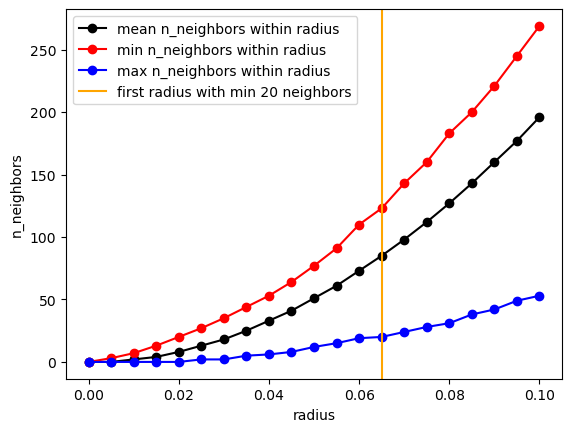

In [8]:
utils.plot_neighs_by_radius(adata)

- It can happen that the max of 50 cells within radius is reached before min of 20 cells. Needs to be decided what is more important for average niche size.
- while distances grow logarithmically, number of cells within radius growths quadratically on average
- important: cells per radius can show us how to fine-tune radii to capture more heterogenous density region: higher coeff_of_variation/z-score indicates high variance in density

let's standardize the cells/circle such that the variance in density becomes comparable between radii:

In [9]:
adata.obs["z_score"] = (adata.obs['cells_in_radius'].values - adata.obs['cells_in_radius'].values.mean())/adata.obs['cells_in_radius'].values.var()

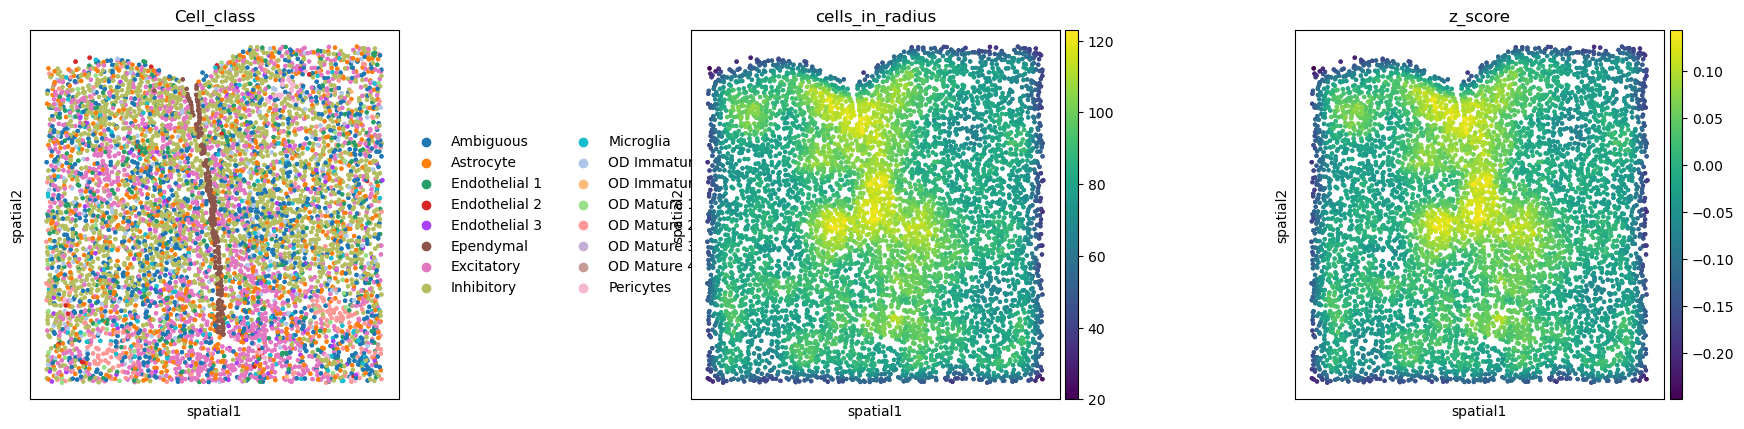

In [10]:
sq.pl.spatial_scatter(adata, color=["Cell_class","cells_in_radius", "z_score"], shape=None)

We clearly see regions of different density. We now have two goals: Find an ideal radius to maximize this variance in z_scores (more informative niches!) while having roughly 20-50 cells per circle and then cluster or segment the slide based on these regions.

in detail this could work as follows:
- find radius such that 20-50 cells within circle and then optimize radius based on spatial variation (see next point)
- calculate Moran's I between different z_scores (i.e. compare slide with itself but with different cells/circle scores used) -> pick highest Moran's I. Alternative: use Variogram approach
- additionally try local Moran's I or Getis Ord to test for distinct spatial hotspots
- after ideal slide was chosen "segment" the slide (an ideal way to do this is still to be figured out...)